### Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colors
from sklearn.preprocessing import MinMaxScaler

### 1) Load Data


In [2]:
df = pd.read_csv(r'D:\NTI\Session-06\data\employee_attrition_course.csv')

## Understand the Dataset

In [32]:
print("Shape:", df.shape)
df.info()
df.describe(include='all').T

Shape: (1495, 37)
<class 'pandas.DataFrame'>
RangeIndex: 1495 entries, 0 to 1494
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1451 non-null   float64
 1   Attrition                 1495 non-null   str    
 2   BusinessTravel            1495 non-null   str    
 3   DailyRate                 1495 non-null   int64  
 4   Department                1495 non-null   str    
 5   DistanceFromHome          1495 non-null   int64  
 6   Education                 1495 non-null   int64  
 7   EducationField            1466 non-null   str    
 8   EmployeeCount             1495 non-null   int64  
 9   EmployeeNumber            1495 non-null   int64  
 10  EnvironmentSatisfaction   1495 non-null   int64  
 11  Gender                    1495 non-null   str    
 12  HourlyRate                1495 non-null   int64  
 13  JobInvolvement            1495 non-null   int64  
 14  J

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1451.0,NaN,NaN,NaN,36.973122,9.229636,16.0,30.0,36.0,43.0,78.0
Attrition,1495,2,No,1256,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1495,7,Travel_Rarely,1051,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1495.0,NaN,NaN,NaN,800.762542,403.789611,102.0,465.0,798.0,1157.0,1499.0
Department,1495,3,Research and Development,973,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1495.0,NaN,NaN,NaN,9.44214,9.590084,1.0,2.0,7.0,14.0,150.0
Education,1495.0,NaN,NaN,NaN,2.91505,1.026494,1.0,2.0,3.0,4.0,5.0
EducationField,1466,6,Life Sciences,605,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1495.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1495.0,NaN,NaN,NaN,1027.762542,601.87556,1.0,493.5,1025.0,1556.5,2068.0


## Assess Data Quality

In [ ]:
# Missing values
print(df.isnull().sum()[df.isnull().sum() > 0])

# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Duplicate IDs
print("Duplicate RecordID:", df['RecordID'].duplicated().sum())

# Data types
print(df.dtypes)

# Constant / near-constant columns
for col in df.columns:
    if df[col].nunique() <= 1:
        print("Constant column:", col)

# High-missing columns  
high_missing = df.isnull().mean()[df.isnull().mean() > 0.4]
print(high_missing)

Age                   44
EducationField        29
JobRole               15
MonthlyIncome        120
TotalWorkingYears     61
YearsAtCompany        75
ManagerNotes         897
dtype: int64
Duplicate rows: 25
Duplicate RecordID: 45
Age                         float64
Attrition                       str
BusinessTravel                  str
DailyRate                     int64
Department                      str
DistanceFromHome              int64
Education                     int64
EducationField                  str
EmployeeCount                 int64
EmployeeNumber                int64
EnvironmentSatisfaction       int64
Gender                          str
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                         str
JobSatisfaction               int64
MaritalStatus                   str
MonthlyIncome               float64
MonthlyRate                   int64
NumCompaniesWorked            int64
Over18        

### 2) Cleaning Data

#### 1. Drop Duplicated & Handel Missing Data

In [3]:
def clean_data(df):
    # Drop duplicate rows across all columns
    df = df.drop_duplicates()
    # Replace missing values with the median of each column in: 'Age'
    df = df.fillna({'Age': df['Age'].median()})
    # Replace missing values with "Other" in column: 'JobRole'
    df = df.fillna({'JobRole': "Other"})
    # Replace missing values with 0 in column: 'YearsAtCompany'
    df = df.fillna({'YearsAtCompany': 0})
    # Replace missing values with the median of each column in: 'TotalWorkingYears'
    df = df.fillna({'TotalWorkingYears': df['TotalWorkingYears'].median()})
        # Replace missing values with the median of each column in: 'TotalWorkingYears'
    df = df.fillna({'TotalWorkingYears': df['TotalWorkingYears'].median()})
    # Drop column: 'ManagerNotes'
    df = df.drop(columns=['ManagerNotes'])
    # Drop column: 'Over18'
    df = df.drop(columns=['Over18'])
    # Drop column: 'EmployeeCount'
    df = df.drop(columns=['EmployeeCount'])
    # Drop column: 'EducationField'
    df = df.drop(columns=['EducationField'])
    # Drop column: 'RecordID'
    df = df.drop(columns=['RecordID'])
    return df

df_clean = clean_data(df.copy())
df_clean.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,Yes,Travel_Rarely,1102,sales,1,2,1,2,Female,...,1,80,0,8.0,0,1,6.0,4,0,5
1,49.0,No,Travel_Frequently,279,Research and Development,8,1,2,3,Male,...,4,80,1,10.0,3,3,10.0,7,1,7
2,37.0,Yes,Travel_Rarely,1373,Research and Development,2,2,4,4,Male,...,2,80,0,7.0,3,3,0.0,0,0,0
3,33.0,No,Travel_Frequently,1392,Research and Development,3,4,5,4,Female,...,3,80,0,8.0,3,3,0.0,7,3,0
4,27.0,No,Travel_Rarely,591,Research and Development,2,1,7,1,Male,...,4,80,1,6.0,3,3,2.0,2,2,2


In [4]:
df_clean['Age'] = df_clean['Age'].clip(lower=18) # Clip Age values to be at least 18
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].clip(lower=0, upper=30000) # Clip MonthlyIncome values to be between 0 and 30000
df_clean = df_clean.fillna({'MonthlyIncome': df_clean['MonthlyIncome'].median()})
print(df_clean['MonthlyIncome'].min())
print(df_clean['MonthlyIncome'].max())
df_clean.head()

1009.0
30000.0


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,Yes,Travel_Rarely,1102,sales,1,2,1,2,Female,...,1,80,0,8.0,0,1,6.0,4,0,5
1,49.0,No,Travel_Frequently,279,Research and Development,8,1,2,3,Male,...,4,80,1,10.0,3,3,10.0,7,1,7
2,37.0,Yes,Travel_Rarely,1373,Research and Development,2,2,4,4,Male,...,2,80,0,7.0,3,3,0.0,0,0,0
3,33.0,No,Travel_Frequently,1392,Research and Development,3,4,5,4,Female,...,3,80,0,8.0,3,3,0.0,7,3,0
4,27.0,No,Travel_Rarely,591,Research and Development,2,1,7,1,Male,...,4,80,1,6.0,3,3,2.0,2,2,2


#### 2. Mapping & Strip

In [5]:
df_clean['DistanceFromHome'] = df_clean['DistanceFromHome'].clip(lower=0, upper=29) # Clip DistanceFromHome values to be between 0 and 29
df_clean["Department"] = df_clean["Department"].replace({
    "sales": "Sales",
    "Human Resourses": "Human Resources",
    "Research and Development": "Research & Development"
})
mapping = {
    'Travel Rarely': 'Travel_Rarely',
    'Travel-Rarely': 'Travel_Rarely',
    'TRAVEL_RARELY': 'Travel_Rarely',
    'travel_rarely': 'Travel_Rarely',
    'Travel_Rarely': 'Travel_Rarely',
    'Travel_Frequently': 'Travel_Frequently',
    'Non-Travel': 'Non-Travel'
}
job_role_mapping = {
    'Sales Ex.': 'Sales Executive',
    'Sales Executve': 'Sales Executive',
    'sales executive': 'Sales Executive'
}
df_clean['JobRole'] = df_clean['JobRole'].str.strip()
df_clean['JobRole'] = df_clean['JobRole'].replace(job_role_mapping)
df_clean['BusinessTravel'] = df_clean['BusinessTravel'].replace(mapping)
df_clean['Gender'] = df_clean['Gender'].str.strip().str.capitalize()
df_clean = df_clean.drop(columns=['EmployeeNumber'])

df_clean.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,Yes,Travel_Rarely,1102,Sales,1,2,2,Female,94,...,1,80,0,8.0,0,1,6.0,4,0,5
1,49.0,No,Travel_Frequently,279,Research & Development,8,1,3,Male,61,...,4,80,1,10.0,3,3,10.0,7,1,7
2,37.0,Yes,Travel_Rarely,1373,Research & Development,2,2,4,Male,92,...,2,80,0,7.0,3,3,0.0,0,0,0
3,33.0,No,Travel_Frequently,1392,Research & Development,3,4,4,Female,56,...,3,80,0,8.0,3,3,0.0,7,3,0
4,27.0,No,Travel_Rarely,591,Research & Development,2,1,1,Male,40,...,4,80,1,6.0,3,3,2.0,2,2,2


#### 3. Logical Anomalies

In [6]:
# Identify the indices of rows with the logical anomaly
# (Age - YearsAtCompany should be at least 16 or 18)
error_indices = df_clean[(df_clean['Age'] - df_clean['YearsAtCompany']) < 16].index

# 2. Drop the faulty rows in-place or overwrite the DataFrame
df_clean = df_clean.drop(index=error_indices)

# 3. Verify the operation and check the new shape
print(f"Successfully dropped {len(error_indices)} rows.")
print(f"Updated DataFrame shape: {df_clean.shape}")

Successfully dropped 5 rows.
Updated DataFrame shape: (1465, 31)


In [7]:
# Gather all indices where career timelines contradict logic
anomaly_indices = df[
    (df['YearsInCurrentRole'] > df['YearsAtCompany']) |
    (df['YearsWithCurrManager'] > df['YearsAtCompany']) |
    (df['YearsSinceLastPromotion'] > df['YearsAtCompany']) |
    (df['YearsAtCompany'] > df['TotalWorkingYears'])
].index

print(f"Number of logical anomalies found: {len(anomaly_indices)}")

# 2. Drop the anomalies if any exist
if len(anomaly_indices) > 0:
    df = df.drop(index=anomaly_indices)
    print(f"Successfully dropped {len(anomaly_indices)} anomaly rows.")
else:
    print("Perfect! No logical timeline anomalies were found.")

print(f"Updated DataFrame shape: {df.shape}")

Number of logical anomalies found: 0
Perfect! No logical timeline anomalies were found.
Updated DataFrame shape: (1495, 37)


In [8]:
# Identify the indices of rows with the promotion anomaly
promo_errors = df_clean[df_clean['YearsSinceLastPromotion'] > df_clean['YearsAtCompany']].index
df_clean = df_clean.drop(index=promo_errors)
print(f"Promotion anomalies found: {len(promo_errors)}")

Promotion anomalies found: 46


In [9]:
# Identify the indices of rows with the experience anomaly
experience_errors = df_clean[df_clean['YearsAtCompany'] > df_clean['TotalWorkingYears']].index
df_clean = df_clean.drop(index=experience_errors)
print(f"Total working years anomalies found: {len(experience_errors)}")

Total working years anomalies found: 13


In [10]:
print(df_clean.groupby('JobLevel')['MonthlyIncome'].agg(['min', 'mean', 'max']))

             min          mean      max
JobLevel                               
1         1009.0   3046.276190  30000.0
2         2042.0   5668.177104  30000.0
3         4945.5   9419.002427  13757.0
4         4945.5  14730.414141  17924.0
5         4945.5  18088.007692  19999.0


#### 4. Outlier ( IQR )

In [11]:
# List of columns to handle outliers
time_cols = ['YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager','TotalWorkingYears','MonthlyIncome', 'DistanceFromHome']

for col in time_cols:
    # 1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    
    # 2. Calculate IQR
    IQR = Q3 - Q1
    
    # 3. Define the upper limit (we only care about upper limit since min is 0)
    upper_limit = Q3 + 1.5 * IQR
    
    # 4. Cap the outliers to the upper limit
    df_clean[col] = df_clean[col].clip(upper=upper_limit)
    
    print(f"Column '{col}': Upper limit set to {upper_limit:.2f}")

print("\nOutliers handling completed successfully using IQR capping!")

Column 'YearsAtCompany': Upper limit set to 19.12
Column 'YearsInCurrentRole': Upper limit set to 14.50
Column 'YearsSinceLastPromotion': Upper limit set to 5.00
Column 'YearsWithCurrManager': Upper limit set to 14.50
Column 'TotalWorkingYears': Upper limit set to 28.50
Column 'MonthlyIncome': Upper limit set to 14728.00
Column 'DistanceFromHome': Upper limit set to 32.00

Outliers handling completed successfully using IQR capping!


#### 5. Data After Cleaning

In [12]:
df_clean.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,Yes,Travel_Rarely,1102,Sales,1,2,2,Female,94,...,1,80,0,8.0,0,1,6.0,4.0,0,5.0
1,49.0,No,Travel_Frequently,279,Research & Development,8,1,3,Male,61,...,4,80,1,10.0,3,3,10.0,7.0,1,7.0
2,37.0,Yes,Travel_Rarely,1373,Research & Development,2,2,4,Male,92,...,2,80,0,7.0,3,3,0.0,0.0,0,0.0
4,27.0,No,Travel_Rarely,591,Research & Development,2,1,1,Male,40,...,4,80,1,6.0,3,3,2.0,2.0,2,2.0
5,32.0,No,Travel_Frequently,1005,Research & Development,2,2,4,Male,79,...,3,80,0,8.0,2,2,7.0,7.0,3,6.0


In [13]:
# # Extract cleaned data to a new CSV file
# df_clean.to_csv(r'D:\Local\Mix\NTI-ML\NTI-Projects\data\employee_attrition_cleaned.csv', index=False) 

### 3) EDA
*   **Build Visulization** to extract relation between target coloumn and other featuers
*   **All Questions** responded in summary field and recommendations

#### 1. Visulizations To Explore Data

C:\Users\PC\AppData\Local\Temp\ipykernel_25536\2313401669.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Attrition', palette=attrition_colors)


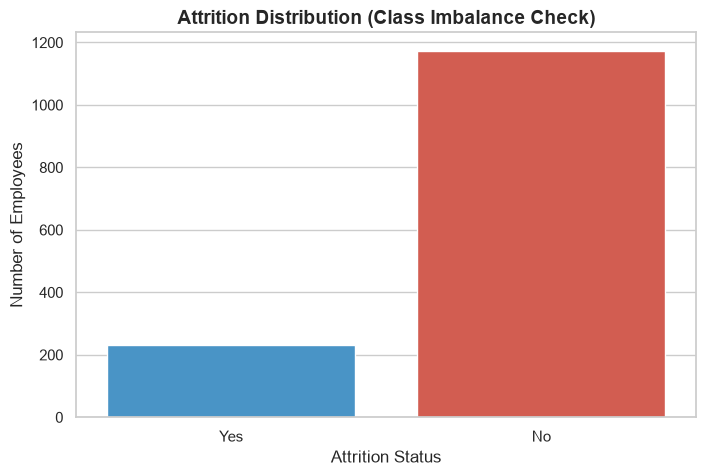

In [14]:
sns.set_theme(style="whitegrid")
# Plot 1: Target Variable Distribution (Class Imbalance Check)
plt.figure(figsize=(8, 5))

# Define a custom color palette (Blue for 'No', Red for 'Yes') for clear contrast
attrition_colors = ['#3498db', '#e74c3c']

# Create the countplot
sns.countplot(data=df_clean, x='Attrition', palette=attrition_colors)

# Add descriptive titles and labels
plt.title('Attrition Distribution (Class Imbalance Check)', fontsize=14, fontweight='bold')
plt.xlabel('Attrition Status', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)

# Display the plot
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_25536\3911514209.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Attrition', y='Age', palette=['#3498db', '#e74c3c'])


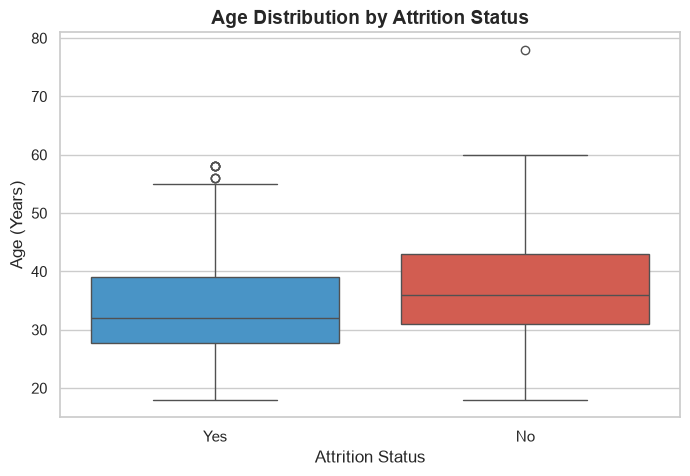

In [15]:
# Plot 2: Age Distribution against Attrition Status
plt.figure(figsize=(8, 5))

# Use the same consistent color palette for Attrition
sns.boxplot(data=df_clean, x='Attrition', y='Age', palette=['#3498db', '#e74c3c'])

# Add descriptive titles and labels
plt.title('Age Distribution by Attrition Status', fontsize=14, fontweight='bold')
plt.xlabel('Attrition Status', fontsize=12)
plt.ylabel('Age (Years)', fontsize=12)

# Display the plot
plt.show()

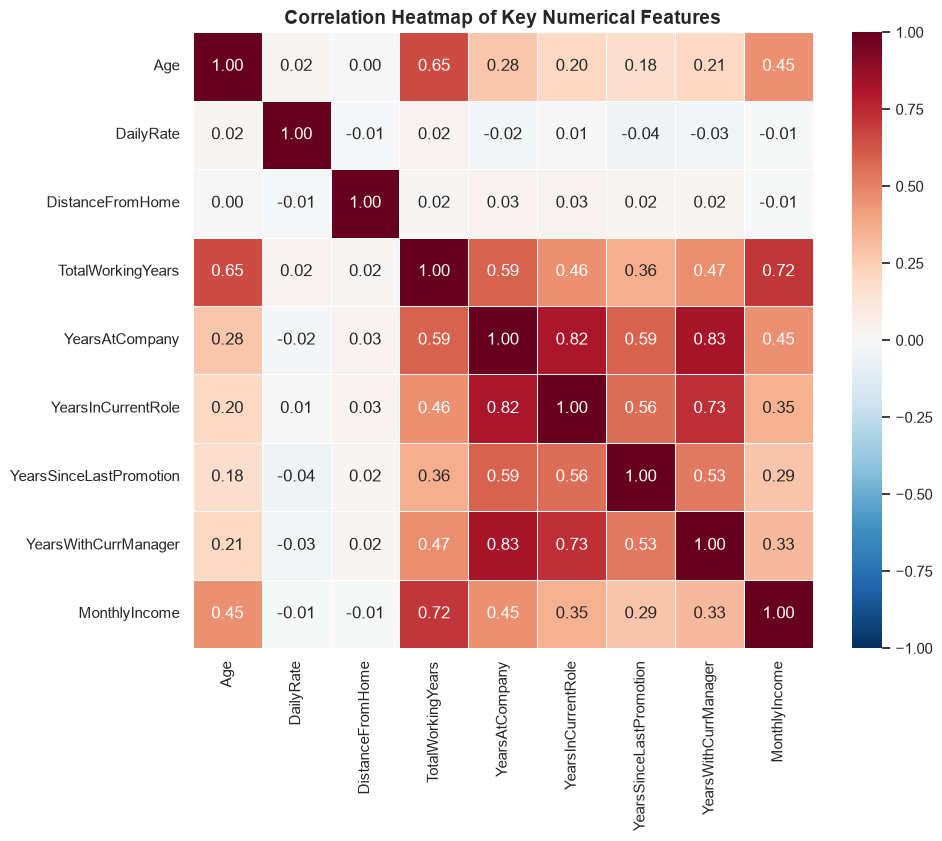

In [16]:
# Plot 3: Correlation Heatmap for Key Numerical Columns
numeric_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'MonthlyIncome']

plt.figure(figsize=(10, 8))

# Calculate the correlation matrix
corr_matrix = df_clean[numeric_cols].corr()

# Create a heatmap with a diverging color map (Red-Blue)
# vmin and vmax ensure the color scale accurately represents values from -1 to 1
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='RdBu_r', 
            fmt=".2f", 
            linewidths=0.5, 
            vmin=-1, 
            vmax=1, 
            center=0)

# Add descriptive title
plt.title('Correlation Heatmap of Key Numerical Features', fontsize=14, fontweight='bold')

# Display the plot
plt.show()

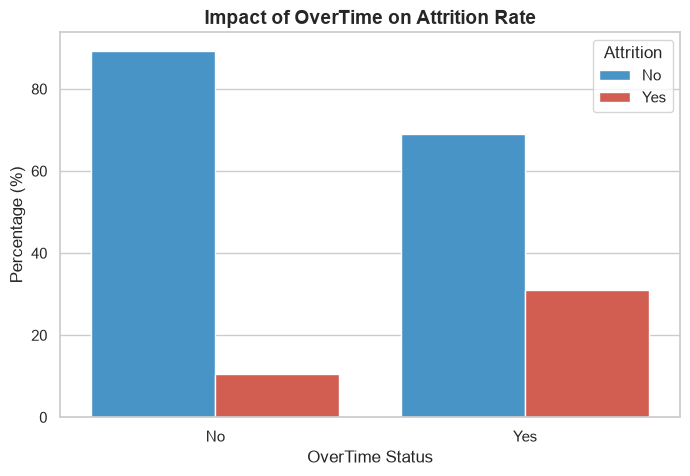

In [17]:
# Plot 4: Impact of OverTime on Attrition Rate
custom_palette = ['#3498db', '#e74c3c']
plt.figure(figsize=(8, 5))

# Calculate the percentage of attrition per OverTime category
ot_attrition = df_clean.groupby('OverTime')['Attrition'].value_counts(normalize=True).rename('Percentage').mul(100).reset_index()

# Create a bar plot to show percentages
sns.barplot(data=ot_attrition, x='OverTime', y='Percentage', hue='Attrition', palette=custom_palette)

# Add titles and labels
plt.title('Impact of OverTime on Attrition Rate', fontsize=14, fontweight='bold')
plt.xlabel('OverTime Status', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)

# Display the plot
plt.show()

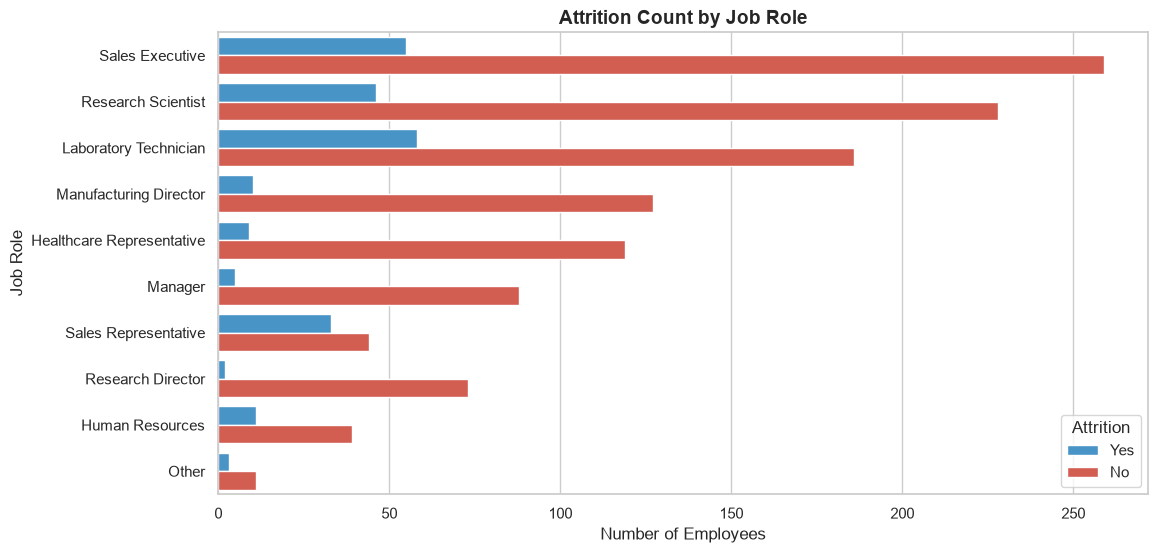

In [18]:
# Plot 5: Attrition Count by Job Role
plt.figure(figsize=(12, 6))

# Create a horizontal count plot, ordered by the most frequent job roles
sns.countplot(data=df_clean, y='JobRole', hue='Attrition', palette=custom_palette, order=df_clean['JobRole'].value_counts().index)

# Add titles and labels
plt.title('Attrition Count by Job Role', fontsize=14, fontweight='bold')
plt.xlabel('Number of Employees', fontsize=12)
plt.ylabel('Job Role', fontsize=12)

# Display the plot
plt.show()

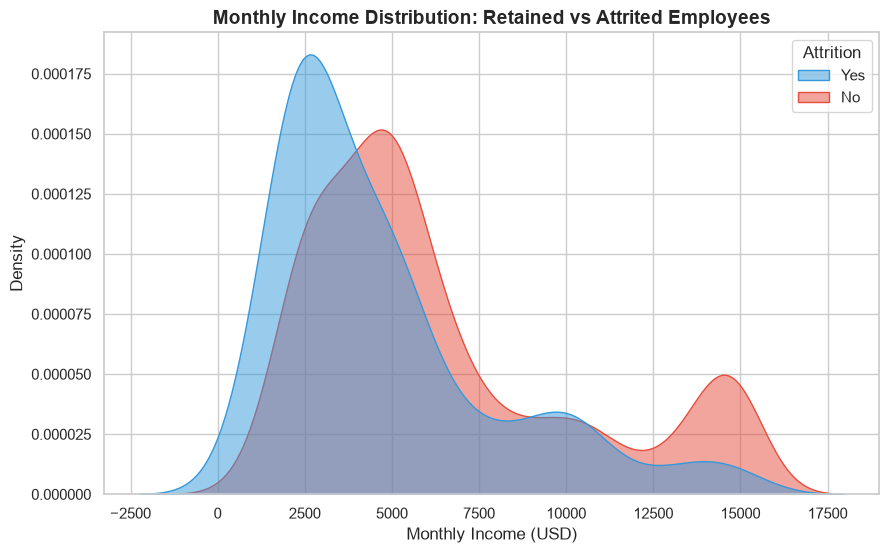

In [19]:
# Plot 6: Monthly Income Distribution (Retained vs Attrited)
plt.figure(figsize=(10, 6))

# Create a KDE (Kernel Density Estimate) plot for smooth distributions
# common_norm=False ensures each distribution is scaled independently for better comparison
sns.kdeplot(data=df_clean, x='MonthlyIncome', hue='Attrition', fill=True, palette=custom_palette, common_norm=False, alpha=0.5)

# Add titles and labels
plt.title('Monthly Income Distribution: Retained vs Attrited Employees', fontsize=14, fontweight='bold')
plt.xlabel('Monthly Income (USD)', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Display the plot
plt.show()

### 4) Prepare Featuers

#### 1. Encoding

In [20]:
# Map Target variable (Attrition) to 0 and 1
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})

# Map Ordinal feature (BusinessTravel) sequentially
travel_mapping = {
    'Non-Travel': 0,
    'Travel_Rarely': 1,
    'Travel_Frequently': 2
}
df_clean['BusinessTravel'] = df_clean['BusinessTravel'].map(travel_mapping)

df_clean = pd.get_dummies(df_clean, columns=['Department'], drop_first=True, dtype=int)

# 1. Map Binary Features (OverTime & Gender) to 0 and 1
df_clean['OverTime'] = df_clean['OverTime'].map({'Yes': 1, 'No': 0})
df_clean['Gender'] = df_clean['Gender'].map({'Male': 1, 'Female': 0})

# 2. One-Hot Encode Nominal Feature (MaritalStatus)
df_clean = pd.get_dummies(df_clean, columns=['MaritalStatus'], drop_first=True, dtype=int)
# 1. Drop the constant column that has zero variance
df_clean = df_clean.drop(columns=['StandardHours'])

#### 2. Scale

In [21]:
df_clean.head()

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Research & Development,Department_Sales,MaritalStatus_Married,MaritalStatus_Single
0,41.0,1,1,1102,1,2,2,0,94,3,...,0,1,6.0,4.0,0,5.0,0,1,0,1
1,49.0,0,2,279,8,1,3,1,61,2,...,3,3,10.0,7.0,1,7.0,1,0,1,0
2,37.0,1,1,1373,2,2,4,1,92,2,...,3,3,0.0,0.0,0,0.0,1,0,0,1
4,27.0,0,1,591,2,1,1,1,40,3,...,3,3,2.0,2.0,2,2.0,1,0,1,0
5,32.0,0,2,1005,2,2,4,1,79,3,...,2,2,7.0,7.0,3,6.0,1,0,0,1


## 5) Executive Summary & Business Recommendations

### Employee Attrition Analysis Summary

### 1. Age Influence on Attrition
**Question:** How does an employee's age influence their decision to leave the company?  
*   **Insight:** Employees who left the company (Attrition = Yes) tend to be younger than those who stayed.  
*   **Details:** The median age for attrited employees is around **31-32 years**, whereas retained employees have a median age of approximately **36**. There are also a few outliers of older employees (55+) leaving, which might indicate early retirements.  
*   **Recommendation:** Focus retention and career development efforts on employees in their **late twenties and early thirties**, as they represent a high-flight-risk demographic.

---

### 2. Impact of Overtime
**Question:** What is the actual impact of working overtime on employee attrition?  
*   **Insight:** Overtime is a significant driver of employee turnover.  
*   **Details:** The attrition rate jumps to approximately **30%** for employees who work overtime (Yes), compared to only **10%** for those who do not (No).  
*   **Recommendation:** Management must review overtime policies to mitigate burnout. If overtime is unavoidable, it must be adequately compensated both financially and through recognition.

---

### 3. Attrition by Job Role
**Question:** Does the attrition rate vary across different job roles?  
*   **Insight:** Yes, there is substantial variation in turnover rates depending on the job role.  
*   **Details:** Roles such as **"Sales Representative"** and **"Laboratory Technician"** experience the highest relative attrition rates. Conversely, senior roles like "Research Director" and "Manager" show very high job stability.  
*   **Recommendation:** Conduct targeted exit interviews to understand the specific daily challenges facing sales and laboratory teams, such as excessive workload or unrealistic targets.

---

### 4. Monthly Income Correlation
**Question:** How does Monthly Income correlate with the decision to stay or leave?  
*   **Insight:** Low income acts as a strong push factor, while higher income provides significant stability.  
*   **Details:** The vast majority of attrited employees are concentrated in the lower income bracket (around **$2,500 monthly**). Attrition drops sharply once income exceeds $5,000 and is almost nonexistent above $12,500.  
*   **Recommendation:** Re-evaluate the compensation structure for entry-level and lower-paying roles to ensure market competitiveness.

---

### Executive Summary
Based on the data analysis, the **"highest-risk" profile** for leaving the company is a young employee (early 30s), working as a Laboratory Technician or Sales Representative, earning a relatively low salary (under $3,000), and burdened with consistent overtime. 

**Key Strategic Actions:**
1. Address compensation disparities for junior roles.
2. Actively manage and reduce overtime requirements.
3. Provide better support and resources for high-stress positions.

---
**Final Report Created With Presentation**    
---

**Needed**
* Add Featuers name in summary
* Create Scale
* Create Step 7
* Create Presentation

## Feature Engineering

In [ ]:
# 1. Income per Working Year 
df_clean['Income_per_Working_Year'] = df_clean['MonthlyIncome'] / (df_clean['TotalWorkingYears'] + 1)

# 2. Experience Level 
conditions_exp = [
    (df_clean['TotalWorkingYears'] <= 5),
    (df_clean['TotalWorkingYears'] > 5) & (df_clean['TotalWorkingYears'] <= 15),
    (df_clean['TotalWorkingYears'] > 15)
]
choices_exp = ['Junior', 'Mid', 'Senior']
df_clean['Experience_Level'] = np.select(conditions_exp, choices_exp, default='Unknown')

# 3. Promotion Rate
df_clean['Promotion_Rate'] = df_clean['YearsSinceLastPromotion'] / (df_clean['YearsAtCompany'] + 1)

# 4. Employee Tenure Groups
conditions_tenure = [
    (df_clean['YearsAtCompany'] <= 1),
    (df_clean['YearsAtCompany'] > 1) & (df_clean['YearsAtCompany'] <= 3),
    (df_clean['YearsAtCompany'] > 3) & (df_clean['YearsAtCompany'] <= 5),
    (df_clean['YearsAtCompany'] > 5)
]
choices_tenure = ['0-1yr', '1-3yr', '3-5yr', '5yr+']
df_clean['Employee_Tenure_Groups'] = np.select(conditions_tenure, choices_tenure, default='Unknown')

# 5. High Income Indicator
median_income = df_clean['MonthlyIncome'].median()
df_clean['High_Income_Indicator'] = np.where(df_clean['MonthlyIncome'] > median_income, 1, 0)

توزيع مستويات الخبرة في الداتا:
Experience_Level
Junior    1406
Name: count, dtype: int64


## Scaling

In [30]:
numerical_cols = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 
    'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 
    'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
    'Income_per_Working_Year', 'Promotion_Rate'
]

scaler = MinMaxScaler()
df_clean[numerical_cols] = scaler.fit_transform(df_clean[numerical_cols])

df_clean[['Income_per_Working_Year', 'Experience_Level', 'Promotion_Rate', 'Employee_Tenure_Groups', 'High_Income_Indicator']].head(620)

,Income_per_Working_Year,Experience_Level,Promotion_Rate,Employee_Tenure_Groups,High_Income_Indicator
0,0.239770,Junior,0.000000,0-1yr,0
1,0.227314,Junior,0.179399,0-1yr,0
2,0.067698,Junior,0.000000,0-1yr,0
4,0.158459,Junior,0.494675,0-1yr,0
5,0.125413,Junior,0.600000,0-1yr,0
...,...,...,...,...,...
640,0.138740,Junior,0.649741,0-1yr,0
641,0.318465,Junior,0.896996,0-1yr,1
642,0.133392,Junior,0.247337,0-1yr,0
643,0.206293,Junior,0.216580,0-1yr,1
